# 01 Preprocessing

#### \#\#\# *Characterising neighbourhoods* \#\#\#

This notebook is for research question-specific preprocessing.

We perform feature selection on the remaining 90 demographic features, among them sex, age, citizenship, income, housing, cars, welfare benefits, education levels, immigration and socioeconomy, e.g. by removing highly correlated or redundant variables or variables that otherwise added little value. We do binning and data aggregation on age groups, which are collapsed from the original 5-year increments to the categories 0-17 (children), 18-29 (young adults), 30-69 (working age) and 70+ (elderly). We aggregate citizenship and immigration columns to the categories Western (Nordic, old EU, North America, South and Central America), Global South (Africa, Asia and Oceania, Turkey), and Eastern Europe (new EU and former Yugoslavia), while Denmark and Other Europe are kept as is. We could have reduced noise further by removing highly correlated features.

Conflicting party letters are handled by splitting ambiguous columns and renaming the columns to the party names. Later on, we drop all parties that are listed in only Copenhagen or Frederiksberg. 

Outliers are detected with IQR, but these seem to show actual diversity between neighbourhoods rather than being errors in the data, so we keep these in the analyses. The polling area with most outlier values (Nord, Brønshøj - known as Tingbjerg) will also later be itself characterised as an outlier from its cluster.

**Research questions:**

1. How do neighbourhoods in Copenhagen and Frederiksberg cluster based on demographic and socioeconomic characteristics?
2. What distinguishes these clusters?
3. How can outliers, if they exist, be explained? 

**Notes:**

For this research question, we only focus on 2021 data, as this is the year with the newest demographics data, and we want the election data from the same year as the demoographics data.

*Author: loua*

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.max_colwidth", None)

In [2]:
ROOT = '../../'
INPUT_PATH = ROOT + 'processed-data/2021-special/'
DEMO_PATH = INPUT_PATH + 'demo_relative_2021.csv'
VOTES_PATH = INPUT_PATH + 'votes_relative_2021.csv'
OUTPUT_PATH = ROOT + 'processed-data/characterising-neighbourhoods/01_preprocessed.csv'

## Data integration

In [3]:
demographics_2021 = pd.read_csv(DEMO_PATH)
demographics_2021.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 90 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Gruppe                                              61 non-null     int64  
 1   PollingAreaID                                       61 non-null     int64  
 2   Name                                                61 non-null     object 
 3   DistrictNo                                          61 non-null     int64  
 4   District                                            61 non-null     object 
 5   Municipality                                        61 non-null     object 
 6   Sex_Female                                          61 non-null     float64
 7   Sex_Male                                            61 non-null     float64
 8   Age_0-4 years                                       61 non-null     float64
 9   A

In [4]:
elections_2021 = pd.read_csv(VOTES_PATH)
elections_2021.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gruppe               61 non-null     int64  
 1   PollingAreaID        61 non-null     int64  
 2   Name                 61 non-null     object 
 3   DistrictNo           61 non-null     int64  
 4   District             61 non-null     object 
 5   Municipality         61 non-null     object 
 6   Eligible voters      61 non-null     int64  
 7   Voter turnout        61 non-null     float64
 8   Blank votes          61 non-null     float64
 9   Other invalid votes  61 non-null     float64
 10  Valid votes          61 non-null     float64
 11  A                    61 non-null     float64
 12  B                    61 non-null     float64
 13  C                    61 non-null     float64
 14  D                    61 non-null     float64
 15  F                    61 non-null     float

In [5]:
common_cols = ['Gruppe', 'PollingAreaID', 'Name', 'DistrictNo', 'District', 'Municipality']
df = demographics_2021.merge(elections_2021, on=common_cols, how='inner')
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 122 columns):
 #    Column                                              Dtype  
---   ------                                              -----  
 0    Gruppe                                              int64  
 1    PollingAreaID                                       int64  
 2    Name                                                object 
 3    DistrictNo                                          int64  
 4    District                                            object 
 5    Municipality                                        object 
 6    Sex_Female                                          float64
 7    Sex_Male                                            float64
 8    Age_0-4 years                                       float64
 9    Age_10-14 years                                     float64
 10   Age_15-17 years                                     float64
 11   Age_18-19 years                 

### Add interpretable name column for polling areas

In [6]:
prefix_regex = r'^\d+\.\s*(Kreds,\s*)?'
name_clean = df['Name'].str.replace(prefix_regex, '', regex=True)
district_clean = df['District'].str.replace(prefix_regex, '', regex=True)
df['PollingArea'] = name_clean + ', ' + district_clean
df[['Name', 'District', 'PollingArea']].head()

,Name,District,PollingArea
0,1. Østerbro,1. Østerbro,"Østerbro, Østerbro"
1,1. Nord,1. Østerbro,"Nord, Østerbro"
2,1. Syd,1. Østerbro,"Syd, Østerbro"
3,1. Vest,1. Østerbro,"Vest, Østerbro"
4,1. Nordvest,1. Østerbro,"Nordvest, Østerbro"


In [7]:
df.head()

,Gruppe,PollingAreaID,Name,DistrictNo,District,Municipality,Sex_Female,Sex_Male,Age_0-4 years,Age_10-14 years,Age_15-17 years,Age_18-19 years,Age_20-24 years,Age_25-29 years,Age_30-34 years,Age_35-39 years,Age_40-44 years,Age_45-49 years,Age_5-9 years,Age_50-54 years,Age_55-59 years,Age_60-64 years,Age_65-69 years,Age_70- years,Citizenship_Africa,Citizenship_Asia and Oceania,Citizenship_Denmark,Citizenship_Former Yugoslavia,Citizenship_New EU countries,Citizenship_Nordic,Citizenship_North America,Citizenship_Not specified,Citizenship_Old EU countries,Citizenship_Other Europe,Citizenship_South and Central America,Citizenship_Turkey,Income_Gross income top20pct,Income_Median household income,Car_Households with 1 car,Car_Households with 2+ cars,Car_Households with no car,Crime_Number of arrests,Benefit type_Foertidspension,Benefit type_Folkepension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_Homes_Apartment buildings,Housing type_Homes_Detached house,Housing type_Homes_Terraced house,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Year built_Homes_1960-2009,Year built_Homes_2010-9999,Year built_Homes_Before 1960,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Housing tenure_Homes_Almen,Housing tenure_Homes_Andel,Housing tenure_Homes_Ejer,Housing tenure_Homes_Private rental,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Education_18-29 years_Long higher education,Education_18-29 years_Not specified,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Not specified,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Education_Total 18-29 years,Education_Total 30-70+ years,Immigrants_Africa,Immigrants_Asia and Oceania,Immigrants_Former Yugoslavia,Immigrants_New EU countries,Immigrants_Nordic,Immigrants_North America,Immigrants_Not specified,Immigrants_Old EU countries,Immigrants_Other Europe,Immigrants_South and Central America,Immigrants_Turkey,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Eligible voters,Voter turnout,Blank votes,Other invalid votes,Valid votes,A,B,C,D,F,I,J,G,K,N,H,M,U,O,Z,L,R,V,P,E,Ø,Å,Q,T,Y,Æ,0,PollingArea
0,101001,101001,1. Østerbro,1,1. Østerbro,København,52.891659,47.108341,5.481301,4.356766,2.473975,1.914921,10.467806,13.635779,10.075826,6.573705,6.278113,6.830742,4.221822,6.548002,5.603393,3.926231,3.559954,8.051664,0.398406,2.088421,85.728056,0.250610,1.298034,2.306901,0.944609,0.051407,6.001799,0.295592,0.559054,0.077111,2.969178e+07,491202,11.884635,25.261064,62.854301,0.257036,1.567922,10.577047,1.664310,72.201517,99.278966,0.024863,0.571855,98.791929,0.051407,0.912479,13.886126,0.497265,85.616609,13.205244,0.578332,86.216425,17.220544,47.381672,20.946626,14.451158,14.888967,47.997902,23.771638,13.341493,10.987579,0.161018,3.473394,1.387824,26.813372,1.180800,6.785769,11.156264,31.130195,68.869805,6.971904,20.326049,2.774887,9.538675,13.458203,5.827263,0.034686,31.044051,3.052376,5.584461,1.387444,3.383580,2.231998,2.354920,12518,66.783831,1.315789,0.299043,98.385167,16.060790,13.519757,19.598784,1.762918,10.346505,3.404255,0.158055,0.510638,0.389058,0.085106,0.097264,0.218845,0.826748,1.422492,0.133739,0.376900,0.194529,8.887538,0.024316,0.024316,18.626140,2.638298,0.121581,0.291793,0.145897,0.133739,0.00000,"Østerbro, Østerbro"
1,101002,101002,1. Nord,1,1. Østerbro,København,53.354022,46.645978,5.084746,4.738601,2.387205,2.088804,7.985199,11.912151,8.975889,6.326092,6.099308,6.421580,4.571497,6.505132,5.359274,4.440201,4.476009,12.628312,0.537121,3.234662,86.345190,0.322273,1.265218,1.850084,0.620673,0.071616,4.440201,0.489377,0.584865,0.238720,4.167502e+07,469505,15.305885,29.216097,55.478018,0.346145,1.909764,15.600382

## Data reduction and aggregation

**We will drop some columns because they don't tell us much:**

- Valid votes
- Other invalid votes
- Immigrants_Not specified
- Education_Total 18-29 years
- Education_Total 30-70+ years
- Education_30-70+ years_Not specified
- Education_18-29 years_Not specified
- Citizenship_Not specified
- Car_Households with 2+ cars (we just use Car_Households with no car)
- Car_Households with 1 car (we just use Car_Households with no car)
- Sex_Male (we just use Sex_Female)
- Benefit type_Folkepension (we just use 'Age_70- years')


Some columns also show the same trend, but in different ways. This is the case for Housing type_Homes and Housing type_People, Housing tenure_Homes and Housing tenure_People, Year built_Homes and Year built_People. Let's remove the 'Homes' ones.

We'll also aggregate age, immigration and citizenship data by grouping them into smaller bins.

In [8]:
df = df.loc[:, ~df.columns.str.contains(r'_Not\s*specified\s*$', regex=True)]
cols_to_drop = [
    'Valid votes',
    'Other invalid votes',
    'Education_Total 18-29 years',
    'Education_Total 30-70+ years',
    'Year built_Homes_1960-2009',
    'Year built_Homes_2010-9999',
    'Year built_Homes_Before 1960',
    'Housing tenure_Homes_Almen',
    'Housing tenure_Homes_Andel',
    'Housing tenure_Homes_Ejer',
    'Housing tenure_Homes_Private rental',
    'Housing type_Homes_Apartment buildings',
    'Housing type_Homes_Detached house',
    'Housing type_Homes_Terraced house',
    'Sex_Male',
    'Car_Households with 2+ cars',
    'Car_Households with 1 car',
    'Benefit type_Folkepension'
]
df = df.drop(columns=cols_to_drop)

### Aggregate age columns into fewer bins

In [9]:
# A bin for children under the age of 18
df['Age_0-17 years'] = (
    df['Age_0-4 years']
  + df['Age_5-9 years']
  + df['Age_10-14 years']
  + df['Age_15-17 years']
)

# A bin for young people, students will often go here
df['Age_18-29 years'] = (
    df['Age_18-19 years']
  + df['Age_20-24 years']
  + df['Age_25-29 years']
)

# A bin for people in the 'working age'
df['Age_30-69 years'] = (
    df['Age_30-34 years']
  + df['Age_35-39 years']
  + df['Age_40-44 years']
  + df['Age_45-49 years']
  + df['Age_50-54 years']
  + df['Age_55-59 years']
  + df['Age_60-64 years']
  + df['Age_65-69 years']
)

age_keep = {
    'Age_0-17 years',
    'Age_18-29 years',
    'Age_30-69 years',
    'Age_70- years'
}
df = df.drop(
    columns=[c for c in df.columns if c.startswith('Age_') and c not in age_keep]
)

### Aggregate citizenship, immigrations columns into fewer bins

In [10]:
cit_imm_cols = df.columns[
    df.columns.str.startswith(('Citizenship_', 'Immigrants_'))
].tolist()
cit_imm_cols

['Citizenship_Africa',
 'Citizenship_Asia and Oceania',
 'Citizenship_Denmark',
 'Citizenship_Former Yugoslavia',
 'Citizenship_New EU countries',
 'Citizenship_Nordic',
 'Citizenship_North America',
 'Citizenship_Old EU countries',
 'Citizenship_Other Europe',
 'Citizenship_South and Central America',
 'Citizenship_Turkey',
 'Immigrants_Africa',
 'Immigrants_Asia and Oceania',
 'Immigrants_Former Yugoslavia',
 'Immigrants_New EU countries',
 'Immigrants_Nordic',
 'Immigrants_North America',
 'Immigrants_Old EU countries',
 'Immigrants_Other Europe',
 'Immigrants_South and Central America',
 'Immigrants_Turkey']

We want columns representing 'western' or 'global north' countries, columns representing 'eastern europe' and columns representing 'global south' countries. We will define the categories as:

Western:
- Nordic
- North America
- Old EU countries
- South and Central America

Eastern Europe:
- Former Yugoslavia
- New EU countries

Global south:
- Africa
- Asia and Oceania (likely to contain middle eastern countries)
- Turkey

We will keep Citizenship_Denmark as itself. And we will keep _Other Europe, because this likely contains very different countries, e.g. United Kingdom and Russia.

In [11]:
groups = {
    'Western': [
        'Nordic',
        'North America',
        'Old EU countries',
        'South and Central America',
    ],
    'Eastern Europe': [
        'Former Yugoslavia',
        'New EU countries',
    ],
    'Global South': [
        'Africa',
        'Asia and Oceania',
        'Turkey',
    ],
}

def aggregate_group(df, prefix, regions):
    cols = [
        f'{prefix}_{region}'
        for region in regions
        if f'{prefix}_{region}' in df.columns
    ]
    return df[cols].sum(axis=1)

for prefix in ['Citizenship', 'Immigrants']:
    for group_name, regions in groups.items():
        df[f'{prefix}_{group_name}'] = aggregate_group(df, prefix, regions)

cols_to_drop = df.columns[
    df.columns.str.startswith(('Citizenship_', 'Immigrants_')) &
    ~df.columns.str.contains(
        'Denmark|Other Europe|Western|Eastern Europe|Global South'
    )
]
df = df.drop(columns=cols_to_drop)
df.columns.tolist()

['Gruppe',
 'PollingAreaID',
 'Name',
 'DistrictNo',
 'District',
 'Municipality',
 'Sex_Female',
 'Age_70- years',
 'Citizenship_Denmark',
 'Citizenship_Other Europe',
 'Income_Gross income top20pct',
 'Income_Median household income',
 'Car_Households with no car',
 'Crime_Number of arrests',
 'Benefit type_Foertidspension',
 'Benefit type_Kontanthjaelp',
 'Benefit type_Modtager ikke ydelser',
 'Housing type_People_Apartment buildings',
 'Housing type_People_Detached house',
 'Housing type_People_Terraced house',
 'Year built_People_1960-2009',
 'Year built_People_2010-9999',
 'Year built_People_Before 1960',
 'Housing tenure_People_Almen',
 'Housing tenure_People_Andel',
 'Housing tenure_People_Ejer',
 'Housing tenure_People_Private rental',
 'Education_18-29 years_Long higher education',
 'Education_18-29 years_Primary and lower secondary',
 'Education_18-29 years_Vocational training',
 'Education_30-70+ years_Long higher education',
 'Education_30-70+ years_Primary and lower secon

## Data cleaning

### Deal with conflicting party letters

Some party letters are used for another party in Frederiksberg than in Copenhagen, creating inconsistencies in the data, so we'll deal with that.

In [12]:
parties = pd.read_csv(ROOT + 'raw-data/parties/parties.csv', sep=';')
parties = parties[parties['year'] == 2021]
parties.head()

,year,municipality,party letter,party name
40,2021,København,A,Socialdemokratiet
41,2021,København,B,Radikale Venstre
42,2021,København,C,Det Konservative Folkeparti
43,2021,København,D,Nye Borgerlige
44,2021,København,E,Christiania-Listen


In [13]:
grouped = parties.groupby('party letter')['party name'].unique()
conflicting = {}
for party_letter, names in grouped.items():
    if len(names) > 1:
        conflicting[party_letter] = {}
        for _, row in parties[parties['party letter'] == party_letter].iterrows():
            municipality = row['municipality']
            party_name = row['party name']
            conflicting[party_letter][municipality] = party_name
from pprint import pprint
pprint(conflicting)

{'E': {'Frederiksberg': 'Hvid-sten', 'København': 'Christiania-Listen'},
 'H': {'Frederiksberg': 'Havenisse-partiet', 'København': 'Grøn Omstilling'},
 'J': {'Frederiksberg': 'Bitten Vivi Jensen', 'København': 'Hampepartiet'},
 'T': {'Frederiksberg': 'Volt', 'København': 'Frihedslisten'},
 'Æ': {'Frederiksberg': 'Frihedslisten', 'København': 'Bæredygtigt samfund'}}


In [14]:
import string
EXTRA_LETTERS = {'Æ', 'Ø', 'Å', '0'} 
party_letters = [
    c for c in df.columns
    if len(c) == 1 and (c in string.ascii_uppercase or c in EXTRA_LETTERS)
]
id_cols = [c for c in df.columns if c not in party_letters]

long = df.melt(
    id_vars=id_cols,
    value_vars=party_letters,
    var_name='party_letter',
    value_name='votes'
)

party_map = (
    parties
    .query("year == 2021")
    [['municipality', 'party letter', 'party name']]
    .rename(columns={
        'municipality': 'Municipality',
        'party letter': 'party_letter',
        'party name': 'party_name'
    })
)

long = long.merge(
    party_map,
    on=['Municipality', 'party_letter'],
    how='left'
)

long['votes'] = long['votes'].fillna(0)
long = long[long['party_name'].notna()]

long = (
    long
    .groupby(id_cols + ['party_name'], as_index=False)['votes']
    .sum()
)

final = (
    long
    .pivot(
        index=id_cols,
        columns='party_name',
        values='votes'
    )
    .reset_index()
)

final = final.rename(
    columns=lambda c: f"Vote share_{c}" if c not in id_cols else c
)

final.columns.name = None
assert final.shape[0] == df.shape[0]
assert final.filter(like='Frihedslisten').notna().any(axis=None)

In [15]:
import re
def clean_vote_share(col):
    if col.startswith('Vote share_'):
        col = re.sub(r'[\/(),]', '', col)
        col = re.sub(r'  +', ' ', col)
    return col
final = final.rename(columns=clean_vote_share)
final = final.rename(columns={'Blank votes': 'Vote share_Blank votes'})
final.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 81 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Gruppe                                                        61 non-null     int64  
 1   PollingAreaID                                                 61 non-null     int64  
 2   Name                                                          61 non-null     object 
 3   DistrictNo                                                    61 non-null     int64  
 4   District                                                      61 non-null     object 
 5   Municipality                                                  61 non-null     object 
 6   Sex_Female                                                    61 non-null     float64
 7   Age_70- years                                                 61 non-null

In [16]:
final.head(10)

,Gruppe,PollingAreaID,Name,DistrictNo,District,Municipality,Sex_Female,Age_70- years,Citizenship_Denmark,Citizenship_Other Europe,Income_Gross income top20pct,Income_Median household income,Car_Households with no car,Crime_Number of arrests,Benefit type_Foertidspension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Education_18-29 years_Long higher education,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Immigrants_Other Europe,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Eligible voters,Voter turnout,Vote share_Blank votes,PollingArea,Age_0-17 years,Age_18-29 years,Age_30-69 years,Citizenship_Western,Citizenship_Eastern Europe,Citizenship_Global South,Immigrants_Western,Immigrants_Eastern Europe,Immigrants_Global South,Vote share_Alternativet,Vote share_Bitten Vivi Jensen,Vote share_Bæredygtigt samfund,Vote share_Christiania-Listen,Vote share_Copenhagen,Vote share_Danmark for Alle,Vote share_Dansk Folkeparti,Vote share_Det Demokratiske Parti,Vote share_Det Konservative Folkeparti,Vote share_Enhedslisten - De Rød-Grønne,Vote share_Feministisk Initiativ,Vote share_Frihedslisten,Vote share_Grøn Omstilling,Vote share_Hampepartiet,Vote share_Havenisse-partiet,Vote share_Hvid-sten,Vote share_Klimapartiet Momentum,Vote share_Kommunisterne,Vote share_Kommunistisk Parti,Vote share_Kristendemokraterne,Vote share_Kærlighedspartiet Regnbuefolket Befri Christiania,Vote share_Københavnerlisten,Vote share_Liberal Alliance,Vote share_Nye Borgerlige,Vote share_Radikale Venstre,Vote share_Rolig Revolution,Vote share_SF - Socialistisk Folkeparti,Vote share_Socialdemokratiet,Vote share_Veganerpartiet,Vote share_Venstre Danmarks Liberale Parti,Vote share_Volt
0,101001,101001,1. Østerbro,1,1. Østerbro,København,52.891659,8.051664,85.728056,0.295592,2.969178e+07,491202,62.854301,0.257036,1.567922,1.664310,72.201517,98.791929,0.051407,0.912479,13.205244,0.578332,86.216425,14.888967,47.997902,23.771638,13.341493,10.987579,3.473394,1.387824,26.813372,6.785769,11.156264,3.052376,3.383580,2.231998,2.354920,12518,66.783831,1.315789,"Østerbro, Østerbro",16.533865,26.018507,49.395965,9.812363,1.548644,2.563938,55.913978,12.313562,28.685397,2.638298,NaN,0.133739,0.024316,0.024316,0.218845,1.422492,0.000000,19.598784,18.626140,0.121581,0.291793,0.097264,0.158055,NaN,NaN,0.826748,0.085106,0.194529,0.389058,0.145897,0.376900,3.404255,1.762918,13.519757,0.133739,10.346505,16.060790,0.510638,8.887538,NaN
1,101002,101002,1. Nord,1,1. Østerbro,København,53.354022,12.628312,86.345190,0.489377,4.167502e+07,469505,55.478018,0.346145,1.909764,2.196228,67.665314,84.829315,9.369778,3.174982,14.740988,1.778467,83.480544,13.082514,41.798489,35.670514,9.448482,8.264108,3.566313,1.704383,26.267545,9.352621,13.162418,4.627404,4.112808,2.573443,2.479436,6859,65.665549,1.110124,"Nord, Østerbro",16.782048,21.986154,48.603485,7.495822,1.587491,4.010504,39.302885,13.882212,42.187500,2.297297,NaN,0.067568,0.090090,0.000000,0.292793,1.959459,0.000000,21.756757,15.743243,0.045045,0.450450,0.067568,0.337838,NaN,NaN,0.855856,0.135135,0.292793,0.382883,0.135135,0.360360,3.828829,2.274775,12.049550,0.045045,8.963964,15.810811,0.157658,11.599099,NaN
2,101003,101003,1. Syd,1,1. Østerbro,København,51.785940,7.282595,87.656191,0.290294,3.380967e+07,542786,60.194047,0.258740,1.117001,1.072826,74.138584,96.655307,0.498549,0.145147,5.704910,0.000000,94.295090,3.477405,62.437464,23.242844,10.842287,9.400109,3.487011,1.138934,30.657618,6.076917,10.367423,3.

In [17]:
df = final

### Handle missing values

First, we exctract the numeric, relative cols and store the id columns separately

In [18]:
polling_areas = df[['Gruppe', 'PollingArea', 'PollingAreaID', 'Name', 'District', 'Municipality']].copy()
polling_areas['PollingAreaID'] = polling_areas['PollingAreaID'].astype(str)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[numeric_cols]
df_num = df_num.drop(columns=['Gruppe', 'Eligible voters', 'PollingAreaID', 'DistrictNo'])
polling_areas.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gruppe         61 non-null     int64 
 1   PollingArea    61 non-null     object
 2   PollingAreaID  61 non-null     object
 3   Name           61 non-null     object
 4   District       61 non-null     object
 5   Municipality   61 non-null     object
dtypes: int64(1), object(5)
memory usage: 3.0+ KB


Then we will remove columns with parties that only exist in one of the two municipalities.

In [19]:
df_num = df_num.dropna(axis=1)
df_num.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 56 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Sex_Female                                                    61 non-null     float64
 1   Age_70- years                                                 61 non-null     float64
 2   Citizenship_Denmark                                           61 non-null     float64
 3   Citizenship_Other Europe                                      61 non-null     float64
 4   Income_Gross income top20pct                                  61 non-null     float64
 5   Income_Median household income                                61 non-null     int64  
 6   Car_Households with no car                                    61 non-null     float64
 7   Crime_Number of arrests                                       61 non-null

### Outlier detection

Because we have a lot of features, we first do IQR on all the features to detect outliers, and then visually look at the features that contain at least one outlier.

In [20]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = (df_num < lower_bound) | (df_num > upper_bound)

pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Lower bound": lower_bound,
    "Upper bound": upper_bound
}).head()


,Q1,Q3,IQR,Lower bound,Upper bound
Sex_Female,5.019885e+01,5.171099e+01,1.512131e+00,4.793066e+01,5.397918e+01
Age_70- years,5.886812e+00,9.977734e+00,4.090923e+00,-2.495729e-01,1.611412e+01
Citizenship_Denmark,8.171248e+01,8.707914e+01,5.366660e+00,7.366249e+01,9.512913e+01
Citizenship_Other Europe,2.072641e-01,3.920196e-01,1.847555e-01,-6.986912e-02,6.691528e-01
Income_Gross income top20pct,2.365482e+07,3.209219e+07,8.437370e+06,1.099877e+07,4.474824e+07


In [21]:
# Show which features are outliers per polling area
outlier_features_per_row = iqr_outliers.apply(
    lambda row: list(row[row].index),
    axis=1
)
# Count outliers per polling area
outlier_count_per_row = iqr_outliers.sum(axis=1)
# Fraction of features that are outliers per polling area
outlier_fraction_per_row = outlier_count_per_row / df_num.shape[1]

outlier_summary = pd.DataFrame({
    "outlier_count": outlier_count_per_row,
    "outlier_fraction": outlier_fraction_per_row,
    "outlier_features": outlier_features_per_row
})
outlier_summary.sort_values("outlier_fraction", ascending=False).head(10)

,outlier_count,outlier_fraction,outlier_features
28,11,0.196429,"[Citizenship_Denmark, Year built_People_1960-2009, Year built_People_Before 1960, Housing tenure_People_Almen, Housing tenure_People_Private rental, Education_18-29 years_Primary and lower secondary, Education_30-70+ years_Primary and lower secondary, Voter turnout, Age_0-17 years, Citizenship_Eastern Europe, Citizenship_Global South]"
48,10,0.178571,"[Sex_Female, Citizenship_Denmark, Citizenship_Other Europe, Income_Median household income, Year built_People_2010-9999, Year built_People_Before 1960, Citizenship_Western, Citizenship_Eastern Europe, Vote share_Liberal Alliance, Vote share_Venstre Danmarks Liberale Parti]"
50,6,0.107143,"[Housing type_People_Apartment buildings, Housing type_People_Detached house, Housing type_People_Terraced house, Year built_People_1960-2009, Year built_People_2010-9999, Year built_People_Before 1960]"
7,6,0.107143,"[Citizenship_Denmark, Citizenship_Other Europe, Year built_People_2010-9999, Year built_People_Before 1960, Citizenship_Eastern Europe, Vote share_Venstre Danmarks Liberale Parti]"
58,4,0.071429,"[Sex_Female, Age_70- years, Vote share_Det Konservative Folkeparti, Vote share_SF - Socialistisk Folkeparti]"
34,4,0.071429,"[Income_Median household income, Car_Households with no car, Housing type_People_Apartment buildings, Housing type_People_Detached house]"
9,4,0.071429,"[Sex_Female, Crime_Number of arrests, Housing tenure_People_Private rental, Citizenship_Western]"
49,3,0.053571,"[Year built_People_2010-9999, Vote share_Liberal Alliance, Vote share_Venstre Danmarks Liberale Parti]"
10,3,0.053571,"[Income_Gross income top20pct, Housing tenure_People_Private rental, Socioeconomy_Self-employed]"
54,2,0.035714,"[Vote share_Det Konservative Folkeparti, Vote share_SF - Socialistisk Folkeparti]"


In [22]:
# Find features that have at least 1 outlier
features_with_outlier_counts = (
    iqr_outliers
    .sum(axis=0)
    .sort_values(ascending=False)
)
features_with_outliers = features_with_outlier_counts[features_with_outlier_counts > 0].index.tolist()
print(len(features_with_outliers))
pprint(features_with_outliers)


32
['Year built_People_2010-9999',
 'Vote share_Det Konservative Folkeparti',
 'Sex_Female',
 'Housing type_People_Apartment buildings',
 'Citizenship_Eastern Europe',
 'Year built_People_Before 1960',
 'Housing type_People_Detached house',
 'Vote share_SF - Socialistisk Folkeparti',
 'Vote share_Liberal Alliance',
 'Education_30-70+ years_Primary and lower secondary',
 'Housing tenure_People_Private rental',
 'Socioeconomy_Self-employed',
 'Vote share_Venstre Danmarks Liberale Parti',
 'Citizenship_Denmark',
 'Citizenship_Other Europe',
 'Year built_People_1960-2009',
 'Housing tenure_People_Almen',
 'Citizenship_Global South',
 'Income_Median household income',
 'Citizenship_Western',
 'Age_70- years',
 'Vote share_Kærlighedspartiet Regnbuefolket Befri Christiania',
 'Vote share_Frihedslisten',
 'Income_Gross income top20pct',
 'Age_30-69 years',
 'Housing type_People_Terraced house',
 'Age_0-17 years',
 'Voter turnout',
 'Age_18-29 years',
 'Crime_Number of arrests',
 'Car_Household

### Plot outliers

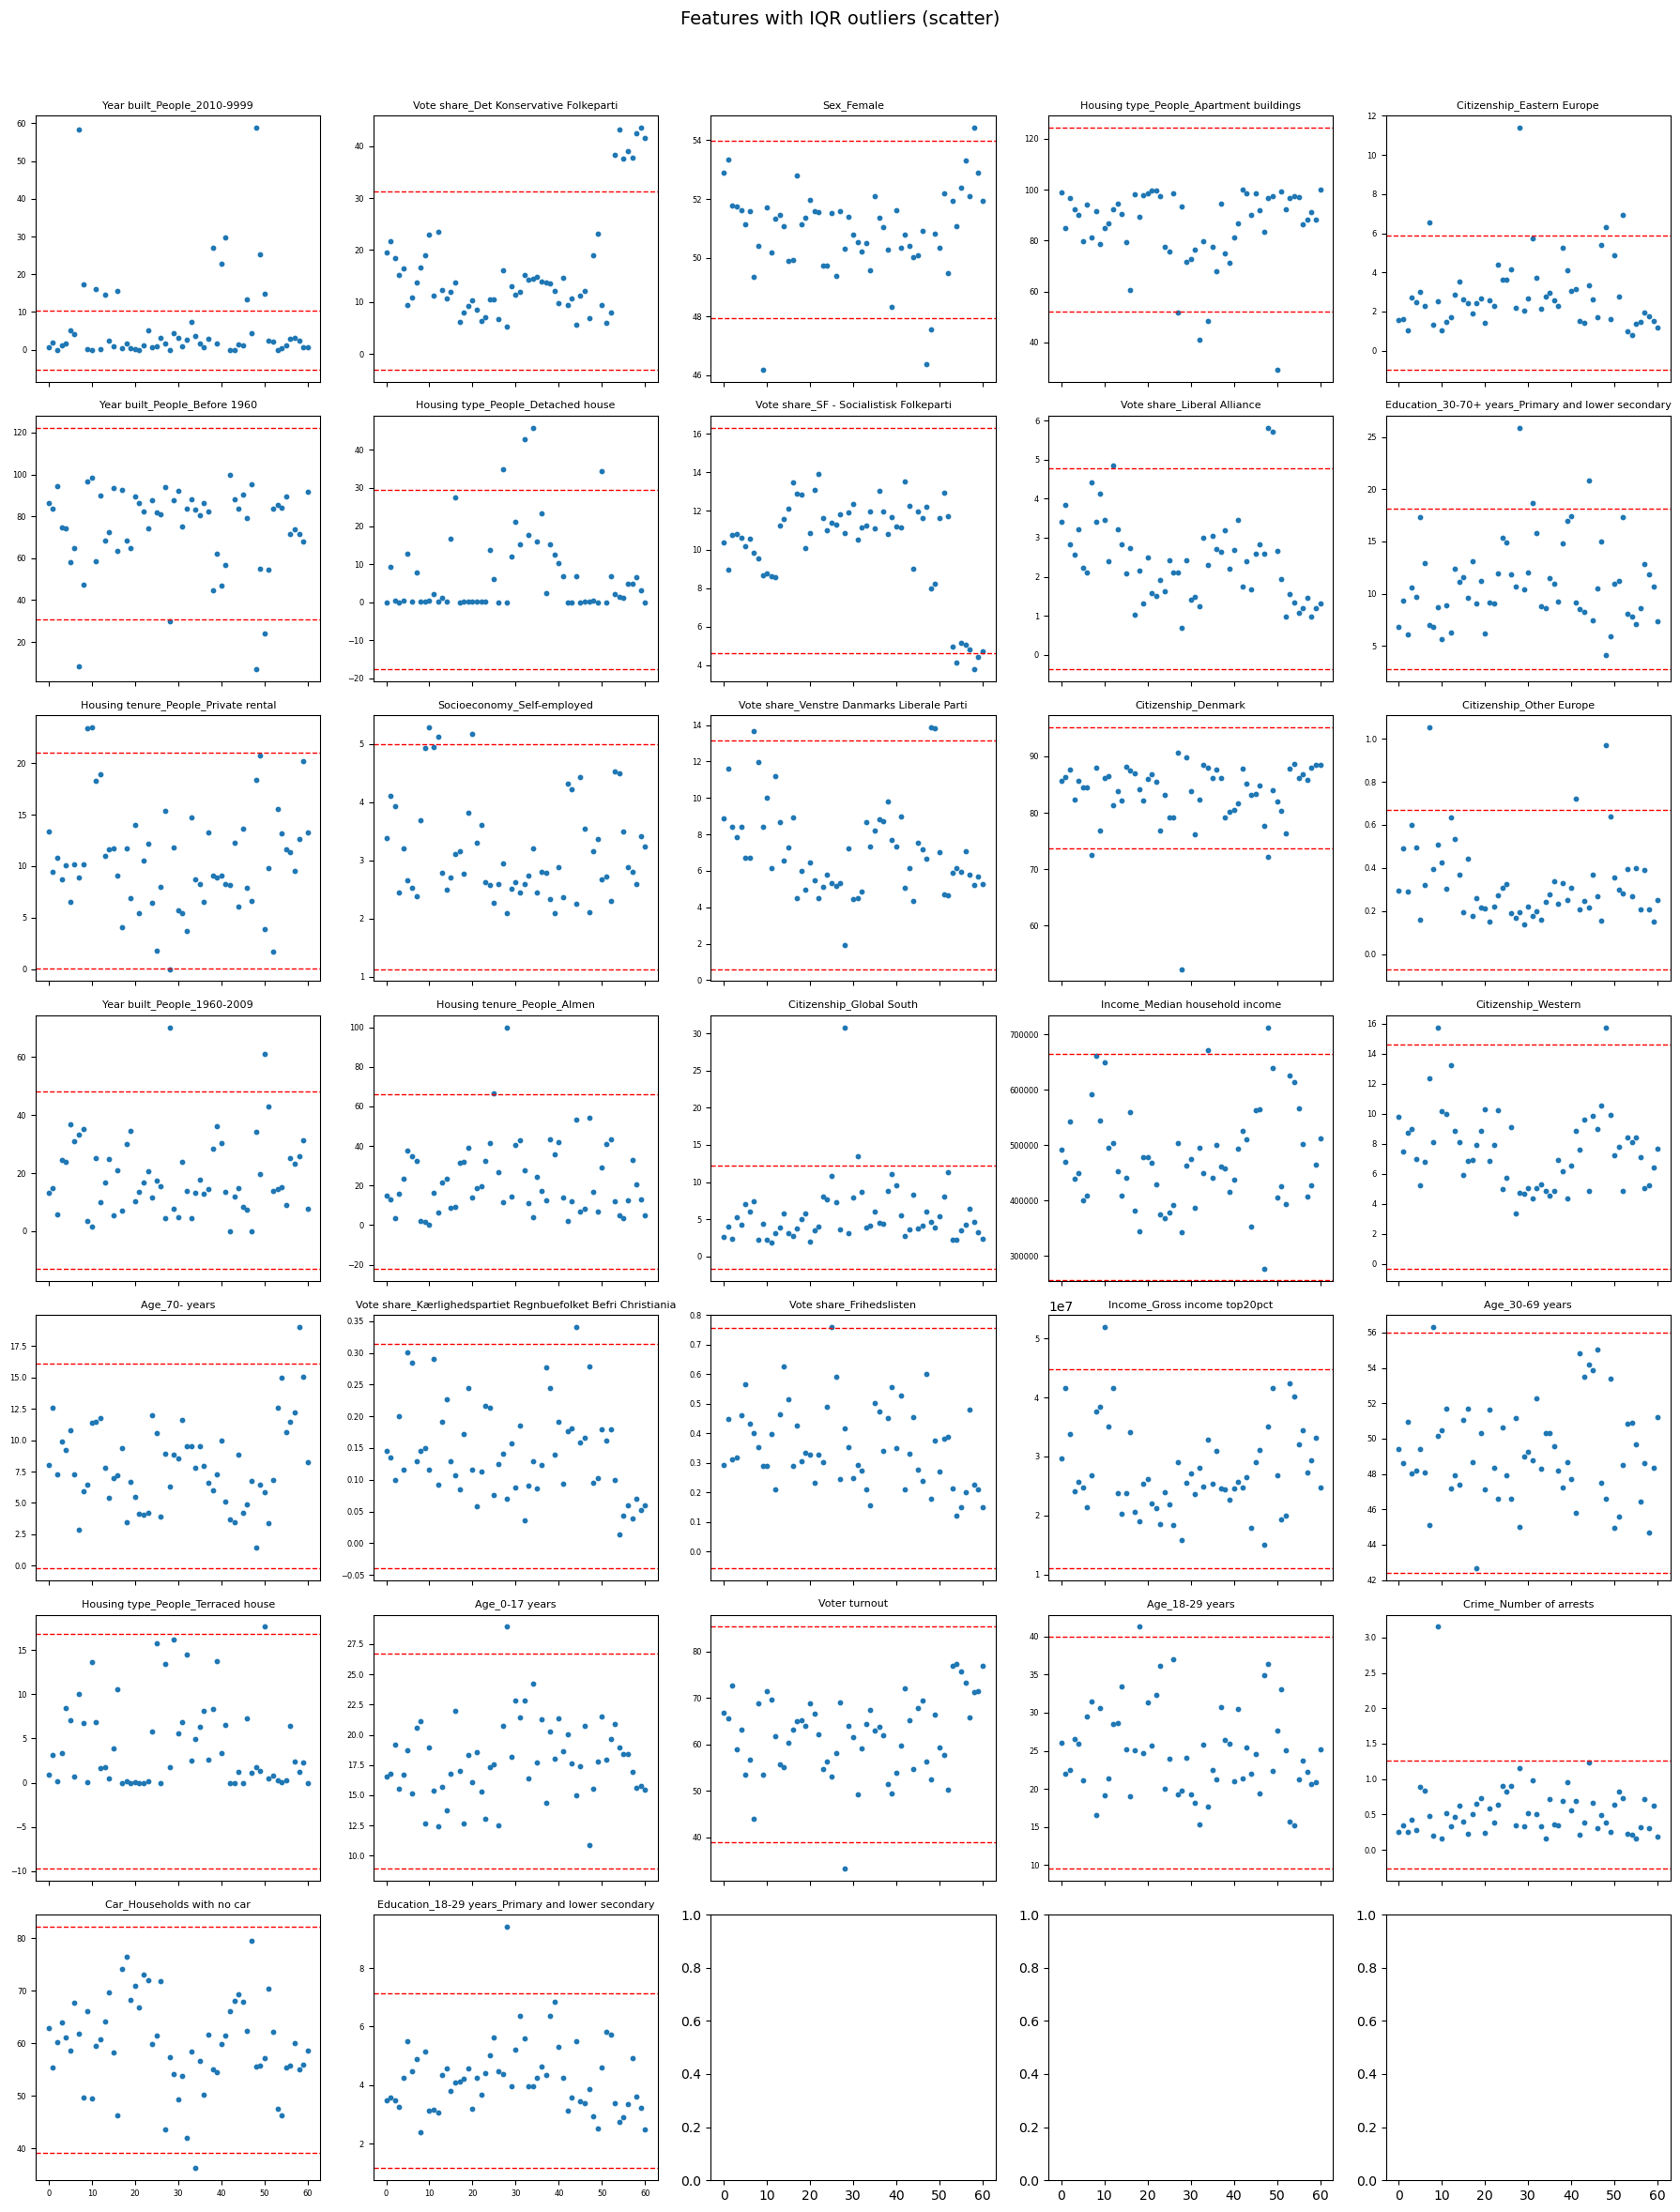

In [23]:
features = features_with_outliers
n_rows, n_cols = 7, 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 24), sharex=True)
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.scatter(df_num.index, df_num[feature], s=10)
    ax.axhline(y=upper_bound[feature], linestyle="--", linewidth=1, color='red')
    ax.axhline(y=lower_bound[feature], linestyle="--", linewidth=1, color='red')
    ax.set_title(feature, fontsize=8)
    ax.tick_params(axis="both", labelsize=6)

fig.suptitle("Features with IQR outliers (scatter)", fontsize=14)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.show()

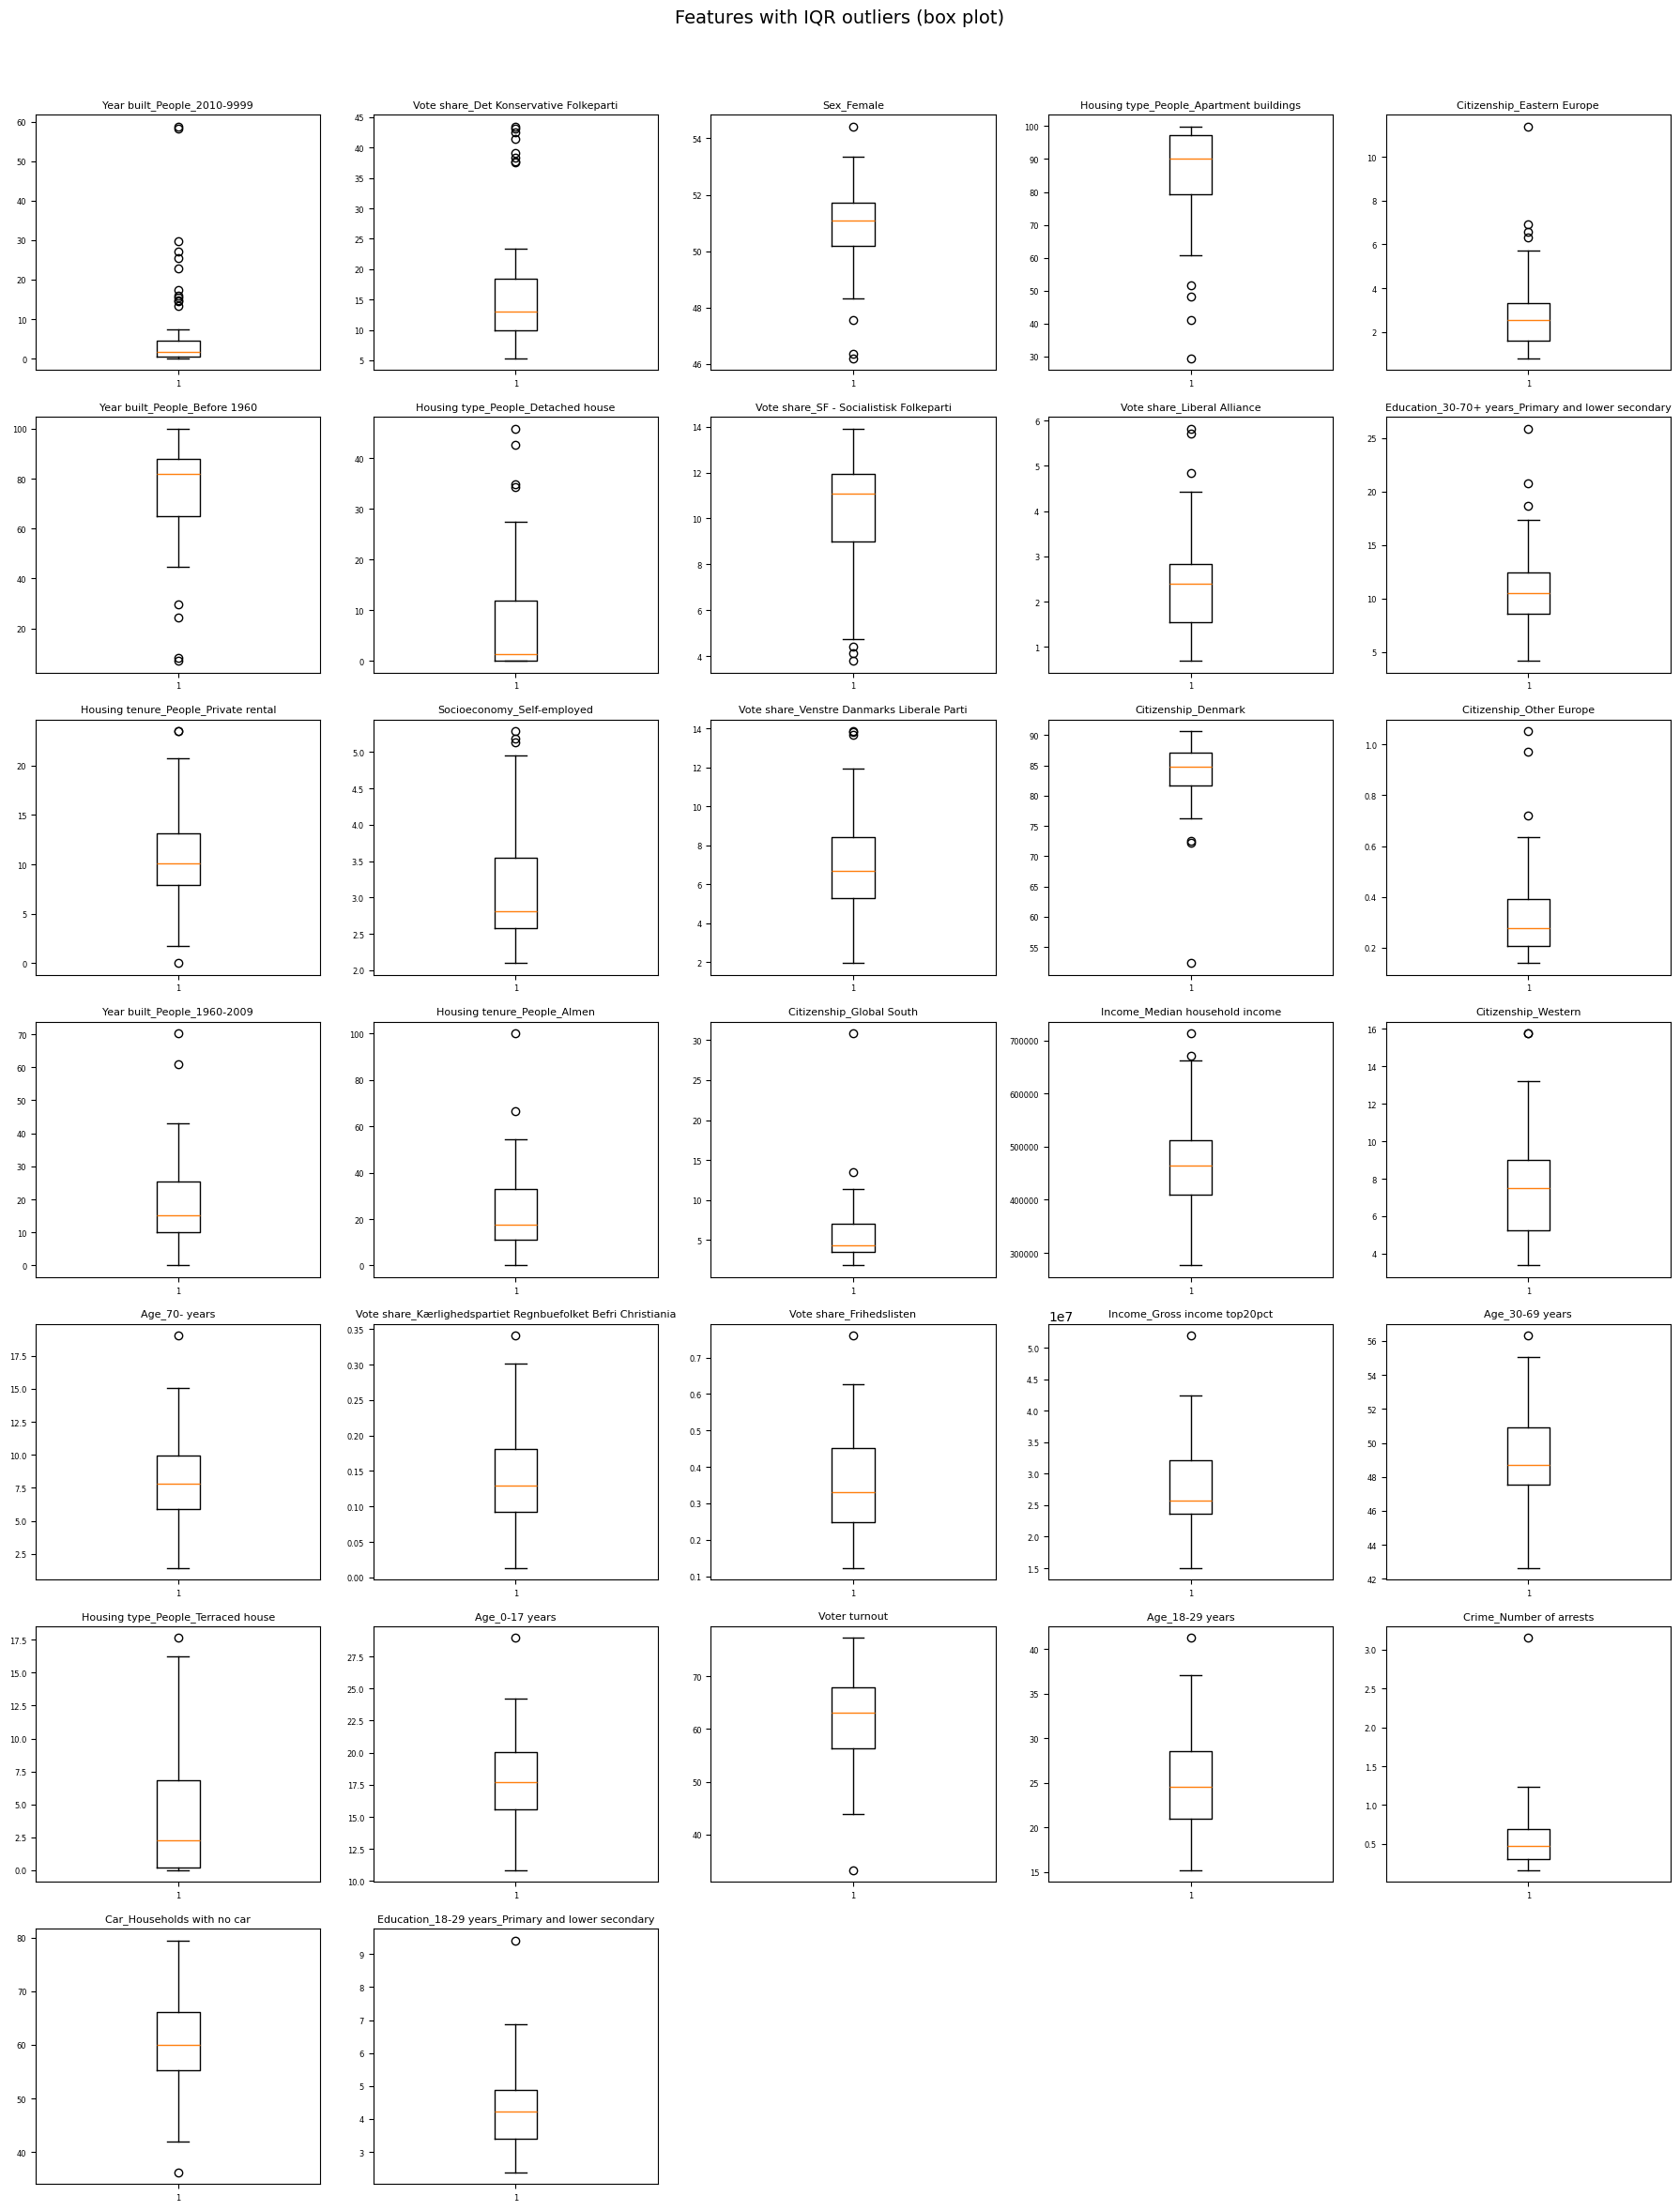

In [24]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 24))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.boxplot(df_num[feature], vert=True)
    ax.set_title(feature, fontsize=8)
    ax.tick_params(axis="both", labelsize=6)

# Hide unused subplots
for ax in axes[len(features):]:
    ax.axis("off")

fig.suptitle("Features with IQR outliers (box plot)", fontsize=14)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.show()

While we do see outliers here, pretty extreme ones too, we don't see any outliers that are so extreme that they seem like actual errors in the data. We are also not interested in removing the very diverse features in the data, because these might be important when clustering polling areas. We are also not interested in removing any polling areas from the analyses entirely, as the goal is to characterise neighbourhoods - not ignore some of them if they fall out of certain bounds.

Because of this, we won't remove or tranform any outlier areas or features.

However, the plots do show some differences between Frederiksberg and Copenhagen. The FRB polling areas (8 rightmost blobs in the scatter plots) are all outliers and grouped together when it comes to votes on Konservative. Not surprisingly, since the votes are from two different local elections (one for CPH, one for FRB), and FRB has a history with Konservative being the largest party.

This is an early hint to what we will find later - that the voting data is a clear divisor between the Frederiksberg polling areas and the Copenhagen polling areas, and that it becomes a domininating factor when clustering neighbourhoods, which we don't want (we explain why in another notebook). For the same reason, we will drop all the voting data later - but not yet.

## Save to CSV

In [25]:
# Reorder columns
prefix_order = [
    'Sex_', 'Age_', 'Education_', 'Income_', 'Socioeconomy_',
    'Benefit type_', 'Housing ', 'Year built_', 'Car_', 'Crime_', 'Immigrants',
    'Citizenship', 'Voter turnout', 'Vote share_'
]
new_order = []
for prefix in prefix_order:
    matched_cols = [c for c in df_num.columns if c.startswith(prefix)]
    new_order.extend(matched_cols)
remaining_cols = [c for c in df_num.columns if c not in new_order]
new_order.extend(remaining_cols)
df_num = df_num[new_order]

In [26]:
polling_areas_reduced = polling_areas[['PollingAreaID', 'PollingArea']]
result_df = pd.concat([polling_areas_reduced, df_num], axis=1)
result_df.to_csv(OUTPUT_PATH, index=False)
result_df

,PollingAreaID,PollingArea,Sex_Female,Age_70- years,Age_0-17 years,Age_18-29 years,Age_30-69 years,Education_18-29 years_Long higher education,Education_18-29 years_Primary and lower secondary,Education_18-29 years_Vocational training,Education_30-70+ years_Long higher education,Education_30-70+ years_Primary and lower secondary,Education_30-70+ years_Vocational training,Income_Gross income top20pct,Income_Median household income,Socioeconomy_Self-employed,Socioeconomy_Top executives,Socioeconomy_Unemployed,Benefit type_Foertidspension,Benefit type_Kontanthjaelp,Benefit type_Modtager ikke ydelser,Housing type_People_Apartment buildings,Housing type_People_Detached house,Housing type_People_Terraced house,Housing tenure_People_Almen,Housing tenure_People_Andel,Housing tenure_People_Ejer,Housing tenure_People_Private rental,Year built_People_1960-2009,Year built_People_2010-9999,Year built_People_Before 1960,Car_Households with no car,Crime_Number of arrests,Immigrants_Other Europe,Immigrants_Western,Immigrants_Eastern Europe,Immigrants_Global South,Citizenship_Denmark,Citizenship_Other Europe,Citizenship_Western,Citizenship_Eastern Europe,Citizenship_Global South,Voter turnout,Vote share_Blank votes,Vote share_Alternativet,Vote share_Dansk Folkeparti,Vote share_Det Konservative Folkeparti,Vote share_Enhedslisten - De Rød-Grønne,Vote share_Frihedslisten,Vote share_Kristendemokraterne,Vote share_Kærlighedspartiet Regnbuefolket Befri Christiania,Vote share_Liberal Alliance,Vote share_Nye Borgerlige,Vote share_Radikale Venstre,Vote share_SF - Socialistisk Folkeparti,Vote share_Socialdemokratiet,Vote share_Veganerpartiet,Vote share_Venstre Danmarks Liberale Parti
0,101001,"Østerbro, Østerbro",52.891659,8.051664,16.533865,26.018507,49.395965,10.987579,3.473394,1.387824,26.813372,6.785769,11.156264,2.969178e+07,491202,3.383580,2.231998,2.354920,1.567922,1.664310,72.201517,98.791929,0.051407,0.912479,14.888967,47.997902,23.771638,13.341493,13.205244,0.578332,86.216425,62.854301,0.257036,3.052376,55.913978,12.313562,28.685397,85.728056,0.295592,9.812363,1.548644,2.563938,66.783831,1.315789,2.638298,1.422492,19.598784,18.626140,0.291793,0.389058,0.145897,3.404255,1.762918,13.519757,10.346505,16.060790,0.510638,8.887538
1,101002,"Nord, Østerbro",53.354022,12.628312,16.782048,21.986154,48.603485,8.264108,3.566313,1.704383,26.267545,9.352621,13.162418,4.167502e+07,469505,4.112808,2.573443,2.479436,1.909764,2.196228,67.665314,84.829315,9.369778,3.174982,13.082514,41.798489,35.670514,9.448482,14.740988,1.778467,83.480544,55.478018,0.346145,4.627404,39.302885,13.882212,42.187500,86.345190,0.489377,7.495822,1.587491,4.010504,65.665549,1.110124,2.297297,1.959459,21.756757,15.743243,0.450450,0.382883,0.135135,3.828829,2.274775,12.049550,8.963964,15.810811,0.157658,11.599099
2,101003,"Syd, Østerbro",51.785940,7.282595,19.222517,22.523034,50.971854,9.400109,3.487011,1.138934,30.657618,6.076917,10.367423,3.380967e+07,542786,3.939106,2.543609,2.581668,1.117001,1.072826,74.138584,96.655307,0.498549,0.145147,3.477405,62.437464,23.242844,10.842287,5.704910,0.000000,94.295090,60.194047,0.258740,3.316021,57.970435,9.109069,29.564523,87.656191,0.290294,8.696201,1.022340,2.328663,72.728727,1.088630,2.396344,0.947392,18.412840,21.098975,0.312082,0.367811,0.100312,2.842176,1.627285,13.999108,10.777976,15.615247,0.412394,8.437361
3,101005,"Vest, Østerbro",51.759808,9.915479,15.529204,26.510660,48.044657,9.414039,3.256990,1.635931,20.925045,10.581499,14.782867,2.405004e+07,438719,2.453323,1.440133,2.708214,2.371641,1.980573,67.913460,92.449855,0.031538,3.355620,15.748988,54.923077,20.647773,8.680162,24.429166,1.078592,74.492242,64.004298,0.428914,4.205726,38.256904,18.039017,39.422346,82.408225,0.599218,8.981960,2.712249,5.279425,59.005636,1.530813,2.464038,1.971231,15.130527,21.297283,0.319659,0.665956,0.199787,2.557272,2.317528,11.827384,10.828450,18.540224,0.665956,7.831646
4,101006,"Nordvest, Østerbro",51.605249,9.186624,16.690146,25.950916,48.172314,9.9093